# 🧠 Parkinson's Disease Detection
## Notebook 2: Data Preprocessing

**Goal:** Prepare the data for model training — drop identifiers, scale features, split dataset correctly.

> ⚠️ **Critical Rule:** The scaler must be fitted ONLY on training data — never on the full dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ✅')

Libraries loaded ✅


## 4.1 Load Data & Separate Features and Target

In [2]:
# Load dataset
df = pd.read_csv('../data/parkinsons.csv')
print(f'Original shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

# Drop the 'name' column — it's just a patient ID, not a feature
df = df.drop(columns=['name'])
print(f'\nAfter dropping "name": {df.shape}')

# X = all features, y = target (status)
X = df.drop(columns=['status'])
y = df['status']

print(f'\nFeatures (X) shape: {X.shape}')
print(f'Target (y) shape: {y.shape}')
print(f'\nTarget distribution:')
print(y.value_counts())
print(f'\nFeature names ({len(X.columns)} features):')
print(X.columns.tolist())

Original shape: (195, 24)
Columns: ['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

After dropping "name": (195, 23)

Features (X) shape: (195, 22)
Target (y) shape: (195,)

Target distribution:
status
1    147
0     48
Name: count, dtype: int64

Feature names (22 features):
['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


## 4.2 Train-Test Split (Stratified)

In [3]:
# Split: 80% training, 20% testing with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Important! Keeps class ratio same in train and test
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')
print(f'\nTraining class distribution:')
print(y_train.value_counts())
print(f'\nTesting class distribution:')
print(y_test.value_counts())

# Verify stratification worked
train_ratio = y_train.mean()
test_ratio = y_test.mean()
print(f'\nPD ratio — Train: {train_ratio:.3f}, Test: {test_ratio:.3f}')
print('✅ Ratios are similar — stratification worked correctly!')

Training samples: 156
Testing samples:  39

Training class distribution:
status
1    118
0     38
Name: count, dtype: int64

Testing class distribution:
status
1    29
0    10
Name: count, dtype: int64

PD ratio — Train: 0.756, Test: 0.744
✅ Ratios are similar — stratification worked correctly!


## 4.3 Feature Scaling (StandardScaler)

In [4]:
# StandardScaler: transforms each feature to mean=0, std=1
# This is critical for SVM and KNN models
scaler = StandardScaler()

# CRITICAL: Fit scaler ONLY on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # only transform (no fit!)

print('Scaling done! ✅')
print(f'Mean of first feature in training: {X_train_scaled[:, 0].mean():.6f}')  # ~0
print(f'Std  of first feature in training: {X_train_scaled[:, 0].std():.6f}')   # ~1
print(f'\nMean of first feature in testing:  {X_test_scaled[:, 0].mean():.4f}')  # not exactly 0 — expected
print(f'Std  of first feature in testing:  {X_test_scaled[:, 0].std():.4f}')

Scaling done! ✅
Mean of first feature in training: -0.000000
Std  of first feature in training: 1.000000

Mean of first feature in testing:  0.0989
Std  of first feature in testing:  1.1309


> **⚠️ Never fit the scaler on test data!** Fitting on all data before splitting is called "data leakage" — it lets the model see test info during training, making results falsely optimistic.

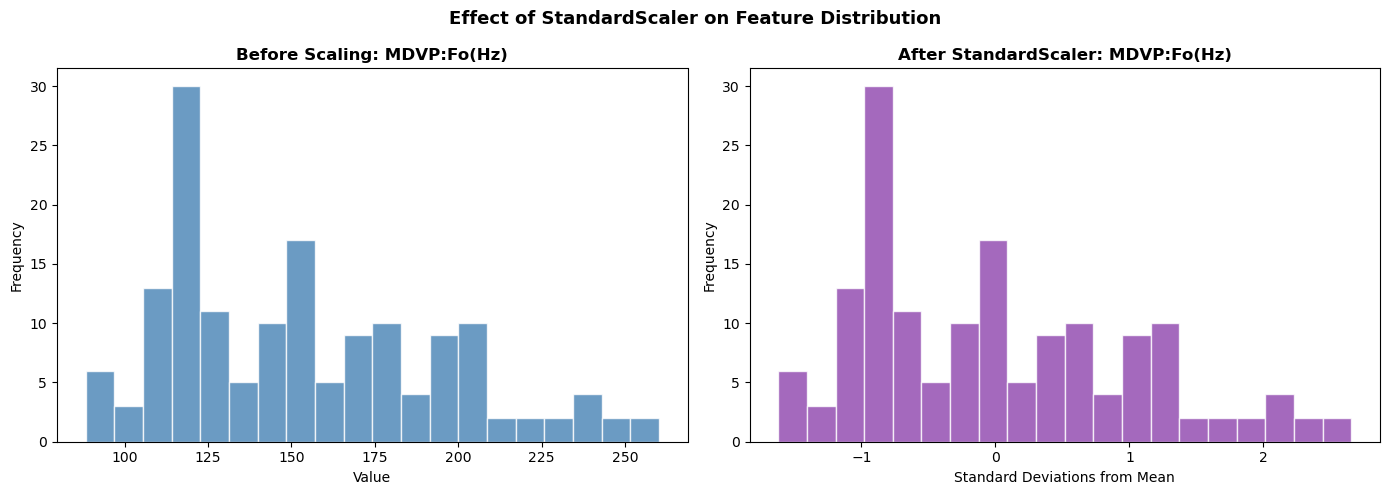

In [5]:
# Visualize effect of scaling
feature_idx = 0
feature_name = X.columns[feature_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].hist(X_train.iloc[:, feature_idx], bins=20, color='steelblue', 
             edgecolor='white', alpha=0.8)
axes[0].set_title(f'Before Scaling: {feature_name}', fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

# After scaling
axes[1].hist(X_train_scaled[:, feature_idx], bins=20, color='#8E44AD', 
             edgecolor='white', alpha=0.8)
axes[1].set_title(f'After StandardScaler: {feature_name}', fontweight='bold')
axes[1].set_xlabel('Standard Deviations from Mean')
axes[1].set_ylabel('Frequency')

plt.suptitle('Effect of StandardScaler on Feature Distribution', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 Save Preprocessed Data for Reuse

In [6]:
# Save all splits and scaler for use in other notebooks
import pickle

preprocessed = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'X_train_scaled': X_train_scaled,
    'X_test_scaled': X_test_scaled,
    'scaler': scaler,
    'feature_names': X.columns.tolist()
}

with open('../results/preprocessed_data.pkl', 'wb') as f:
    pickle.dump(preprocessed, f)

print('✅ Preprocessed data saved to ../results/preprocessed_data.pkl')
print('\nPreprocessing Summary:')
print(f'  • Removed identifier column: name')
print(f'  • Features: {X.shape[1]} voice biomarker columns')
print(f'  • Target: status (1=PD, 0=Healthy)')
print(f'  • Train/Test split: {X_train.shape[0]}/{X_test.shape[0]} samples (80/20)')
print(f'  • Stratified split: class ratios preserved')
print(f'  • Scaler: StandardScaler fitted on train only')

✅ Preprocessed data saved to ../results/preprocessed_data.pkl

Preprocessing Summary:
  • Removed identifier column: name
  • Features: 22 voice biomarker columns
  • Target: status (1=PD, 0=Healthy)
  • Train/Test split: 156/39 samples (80/20)
  • Stratified split: class ratios preserved
  • Scaler: StandardScaler fitted on train only
